# Sales by Branch: Matplotlib Bar Chart and Seaborn Line Plot

      branch  sales
0  Bangalore  47000
1    Chennai  54500
2       Pune  37600


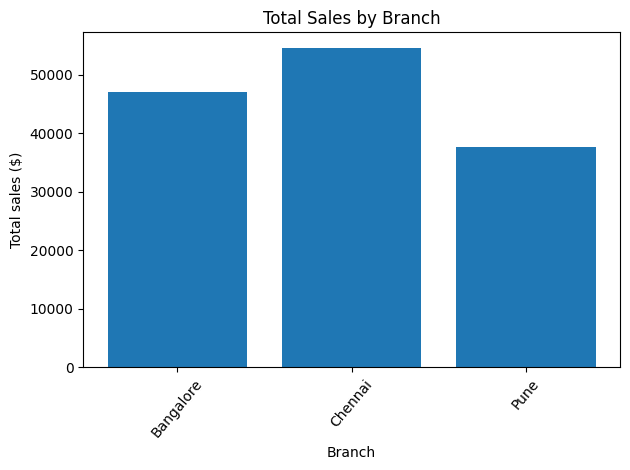

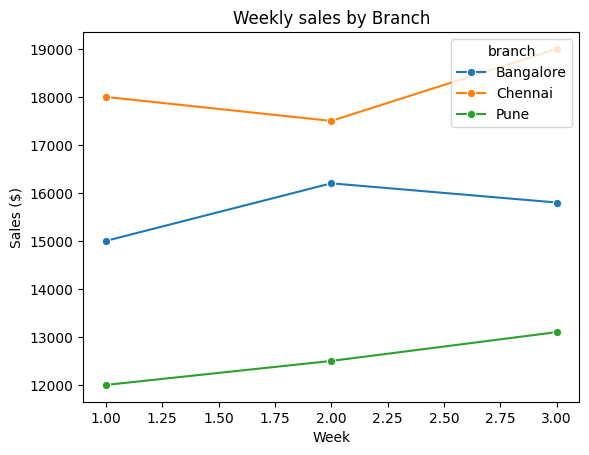

In [1]:
# Import the libraries used in this notebook
import pandas as pd               # data handling: DataFrame, groupby, read_csv
import matplotlib.pyplot as plt   # base plotting library: bar chart, titles, labels, show()
import seaborn as sns             # high-level plotting built on Matplotlib (lineplot with hue)
import io                         # lets us treat a CSV string like a file

# Sample input is already provided as a CSV string below.
csv_data = """branch,week,sales
Bangalore,1,15000
Bangalore,2,16200
Bangalore,3,15800
Chennai,1,18000
Chennai,2,17500
Chennai,3,19000
Pune,1,12000
Pune,2,12500
Pune,3,13100
"""

# io.StringIO wraps the string so pd.read_csv can read it exactly like a CSV file
df = pd.read_csv(io.StringIO(csv_data))

def total_sales_by_branch(df):
    # TODO: group df by 'branch', sum the 'sales' column, and return
    # a plain DataFrame with columns 'branch' and 'sales'

    # groupby('branch') collects the rows of each branch; ['sales'].sum() adds up its weekly sales
    # reset_index() turns 'branch' from the index back into a normal column,
    # so the result is a plain DataFrame that is ready to plot
    branch_totals=df.groupby('branch')['sales'].sum().reset_index()
    return branch_totals
    

def plot_branch_sales(branch_totals):
    # TODO: build a labeled Matplotlib bar chart from branch_totals
    # (title, x-label, y-label with unit, rotated x-tick labels, tight_layout)

    # Bar chart is used to compare one total value across separate categories (branches)
    plt.bar(branch_totals['branch'],branch_totals['sales'])
    plt.title("Total Sales by Branch")      # tells the reader what the chart shows
    plt.xlabel("Branch")                    # describes the x-axis
    plt.ylabel("Total sales ($)")           # describes the y-axis and includes the unit
    plt.xticks(rotation=50)                 # rotates tick labels so they do not overlap
    plt.tight_layout()                      # adjusts spacing so labels are not cut off
    return plt.show()

def plot_weekly_sales(df):
    #sns.lineplot is one of many functions in Seaborn. Others include sns.barplot, sns.scatterplot, sns.histplot, sns.boxplot, and sns.heatmap.

    # Line plot is used to show how a value changes over time (week 1 -> 3)
    # hue='branch' draws a separate coloured line for each branch and adds the legend automatically
    sns.lineplot(data=df,x='week',y='sales',hue='branch' ,marker='o') #marker attribute is used to point the coordinate values like graph
    # Title and labels come from Matplotlib because Seaborn draws on top of Matplotlib
    plt.title("Weekly sales by Branch")
    plt.xlabel("Week")
    plt.ylabel("Sales ($)")
    plt.show()

# Runs only when this file is executed directly (not when it is imported into another file)
if __name__ == "__main__":
    branch_totals = total_sales_by_branch(df)
    print(branch_totals)          # shows the aggregated totals as a table
    plot_branch_sales(branch_totals)   # chart 1: total sales per branch
    plot_weekly_sales(df)              # chart 2: weekly sales trend per branch